<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AUTUMN-ANALYTICS---BRUGADA-/blob/main/AUTUMN_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install wfdb matplotlib numpy

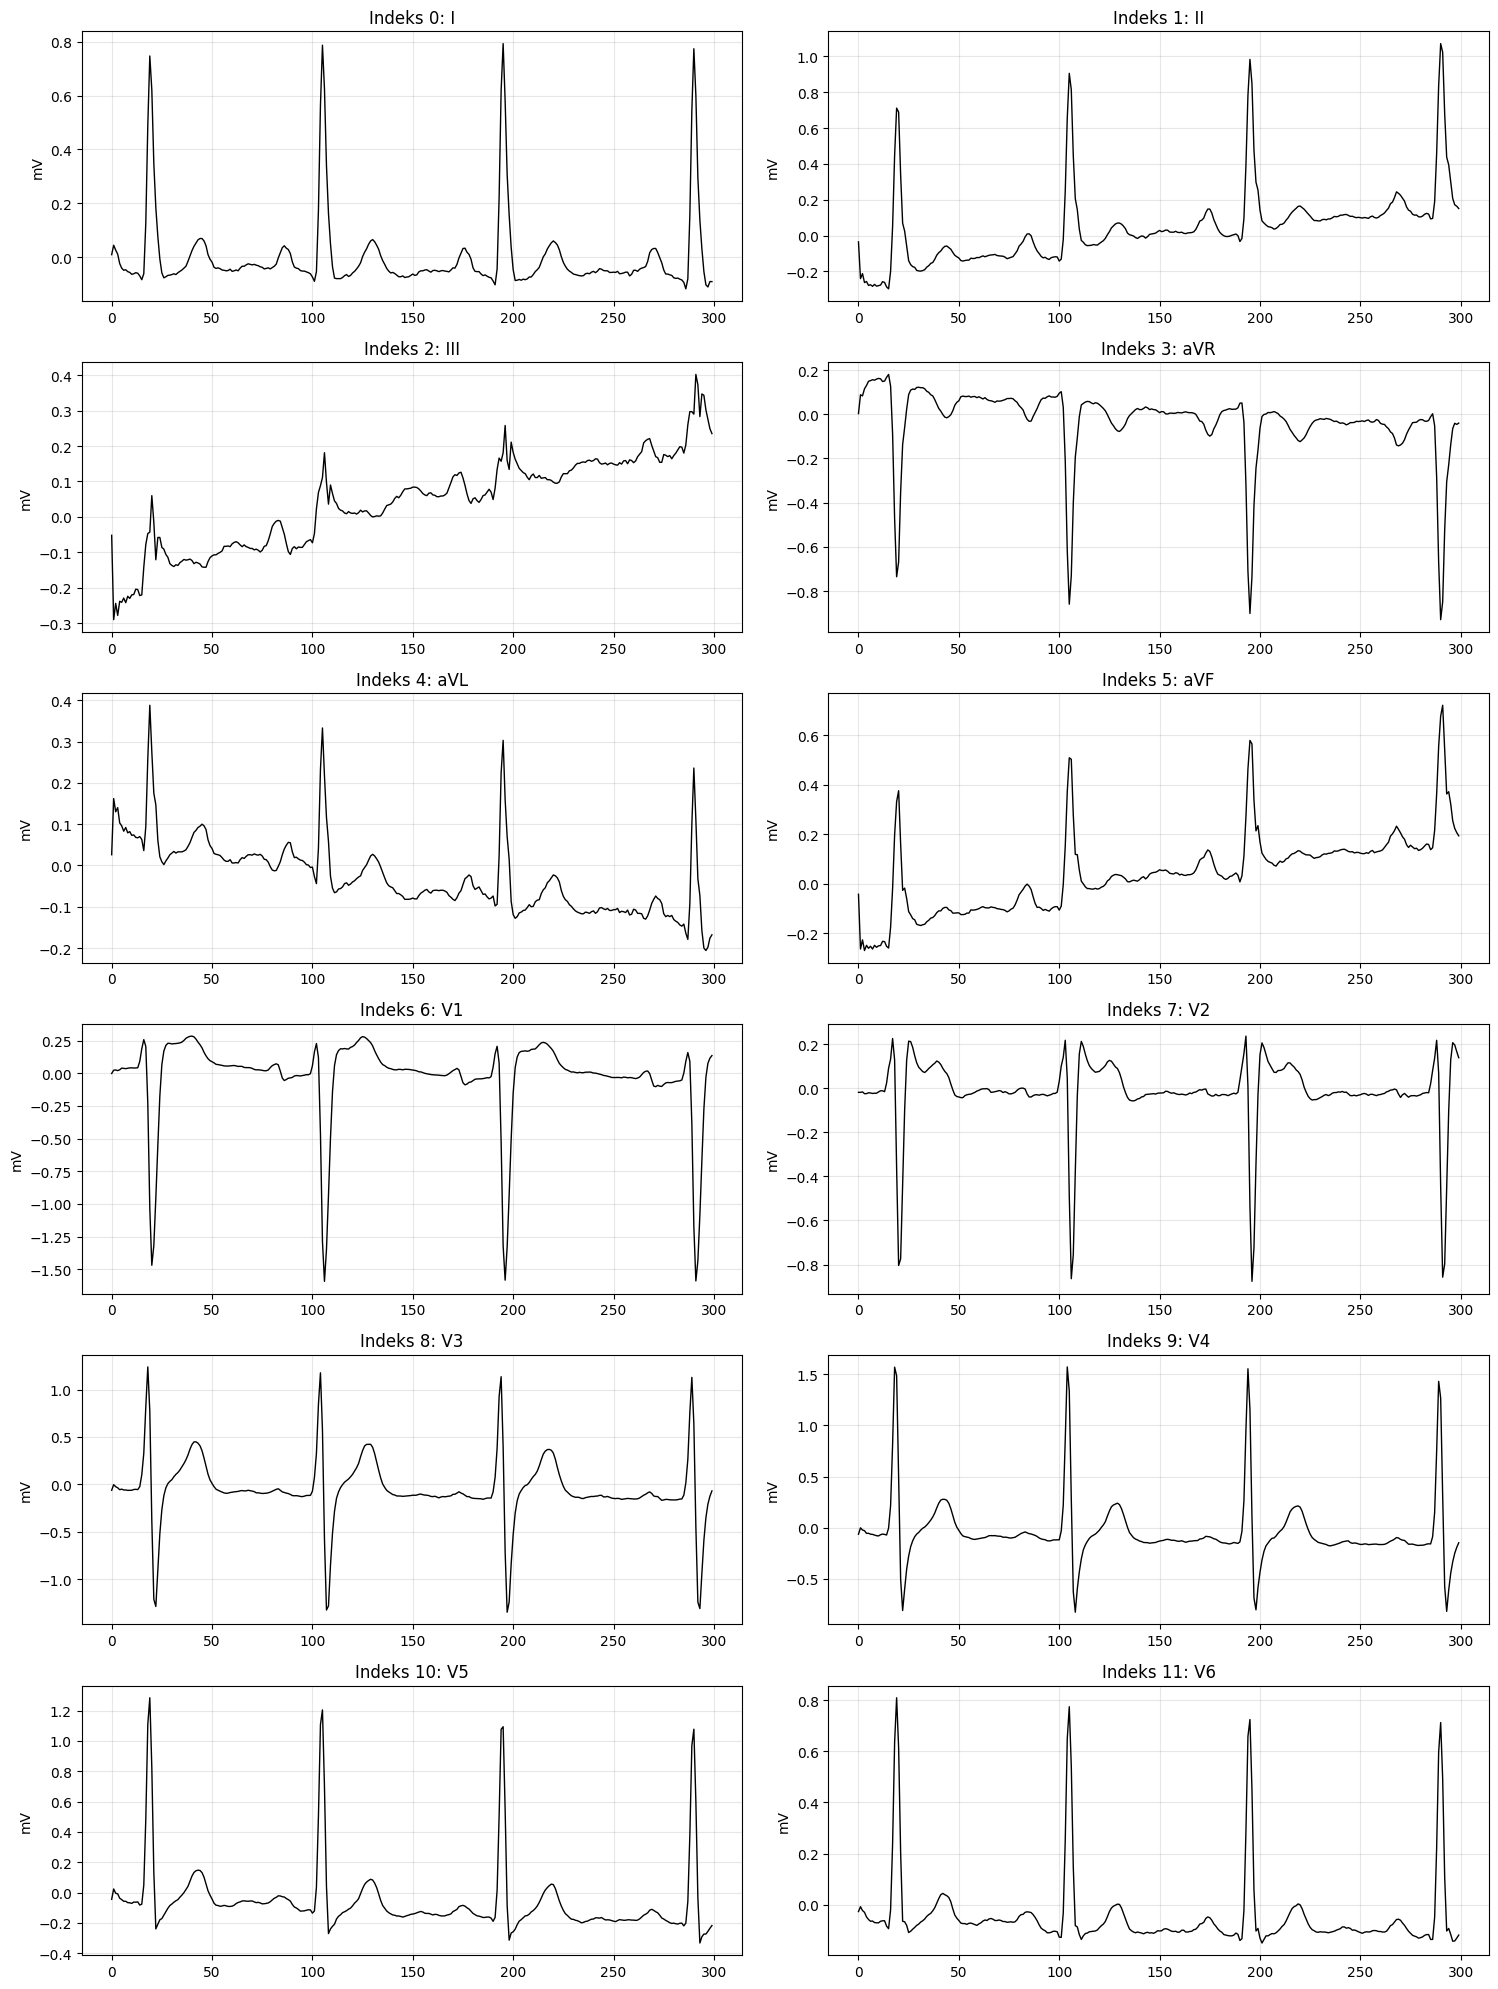

Success! Frequency: 100 Hz | total Lead: 12


In [32]:
import wfdb
import matplotlib.pyplot as plt

file_name = 'PATIENT/251972'
try:
    record = wfdb.rdrecord(file_name)
    fig, axs = plt.subplots(6, 2, figsize=(15, 20))
    axs = axs.flatten()

    for i in range(12):
        axs[i].plot(record.p_signal[:300, i], color='black', linewidth=1)
        axs[i].set_title(f"Indeks {i}: {record.sig_name[i]}")
        axs[i].grid(True, alpha=0.3)
        axs[i].set_ylabel("mV")

    plt.tight_layout()
    plt.show()

    print(f"Success! Frequency: {record.fs} Hz | total Lead: {record.n_sig}")

except Exception as e:
    print(f"error: {e}")

INSTRUCTIONS:

1. Please upload the PATIENT folder and metadata.csv to the Colab sidebar (folder icon on the left).

2. Then click: Run all.

3. Scroll to the bottom to use the Interactive Search Dashboard to visualize any patient's ECG.

Info: Menjalankan mod Sidebar (Bukan Drive).
✅ Sistem: Mengesan data dalam SIDEBAR (Local Content).
🚀 Memulakan pengekstrakan isyarat ECG...
🔎 Menjumpai 363 fail pesakit.


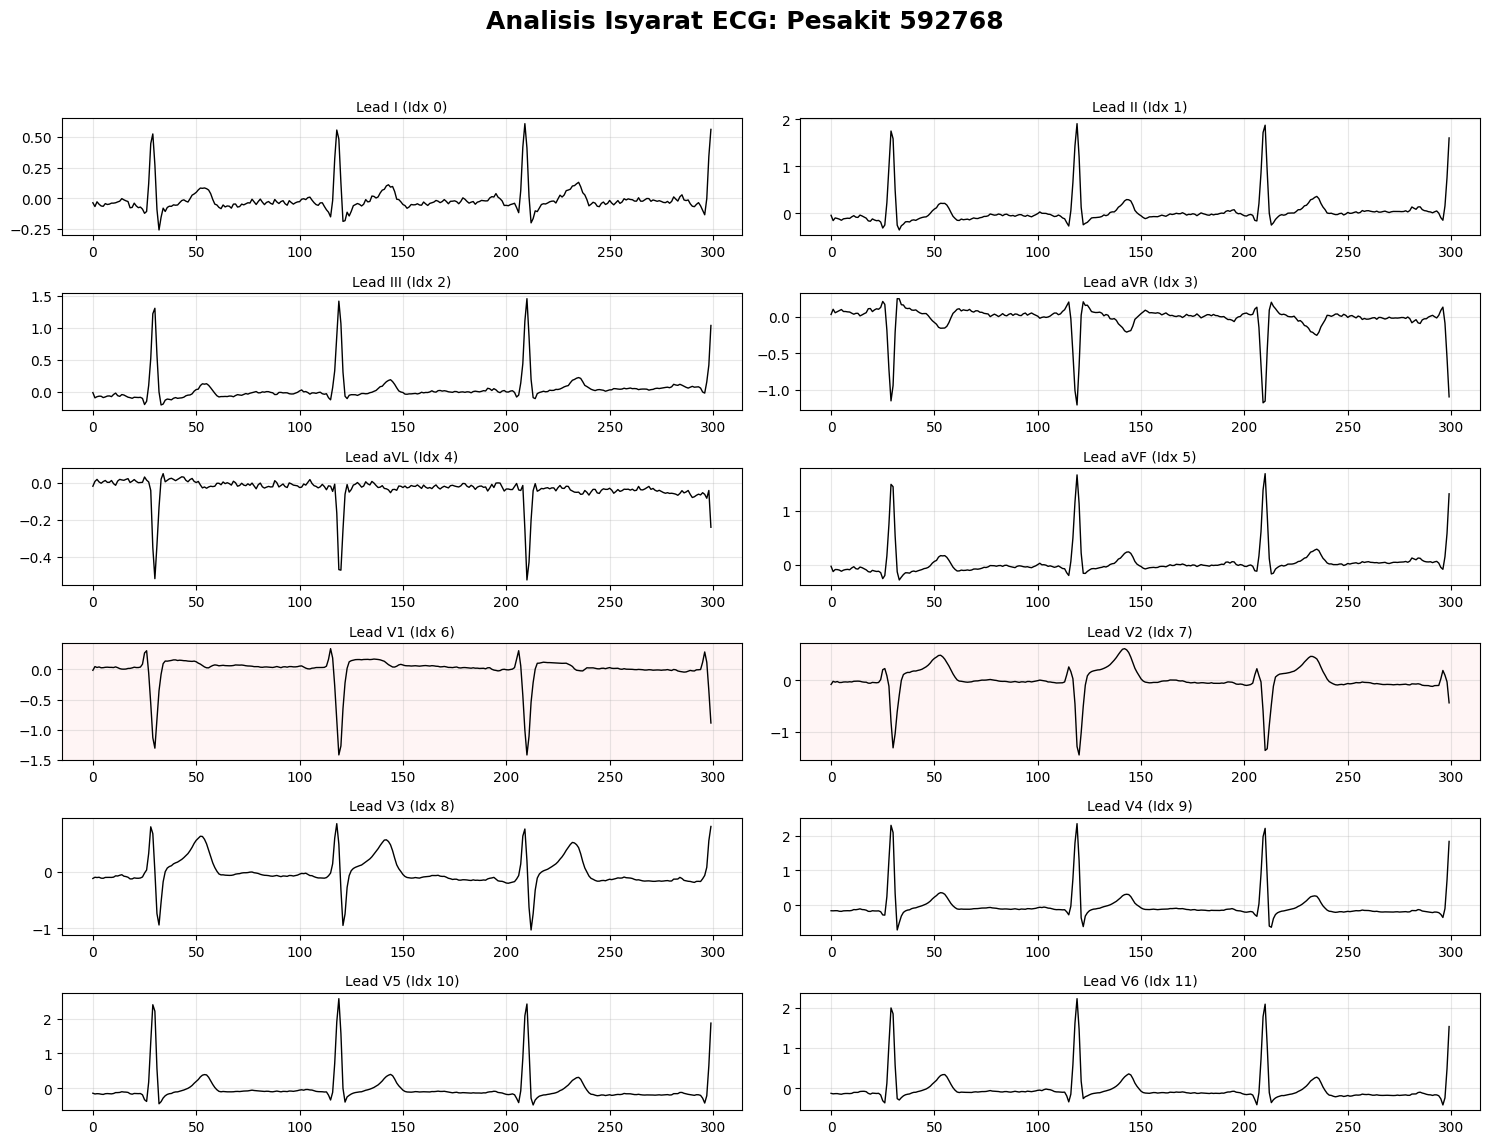

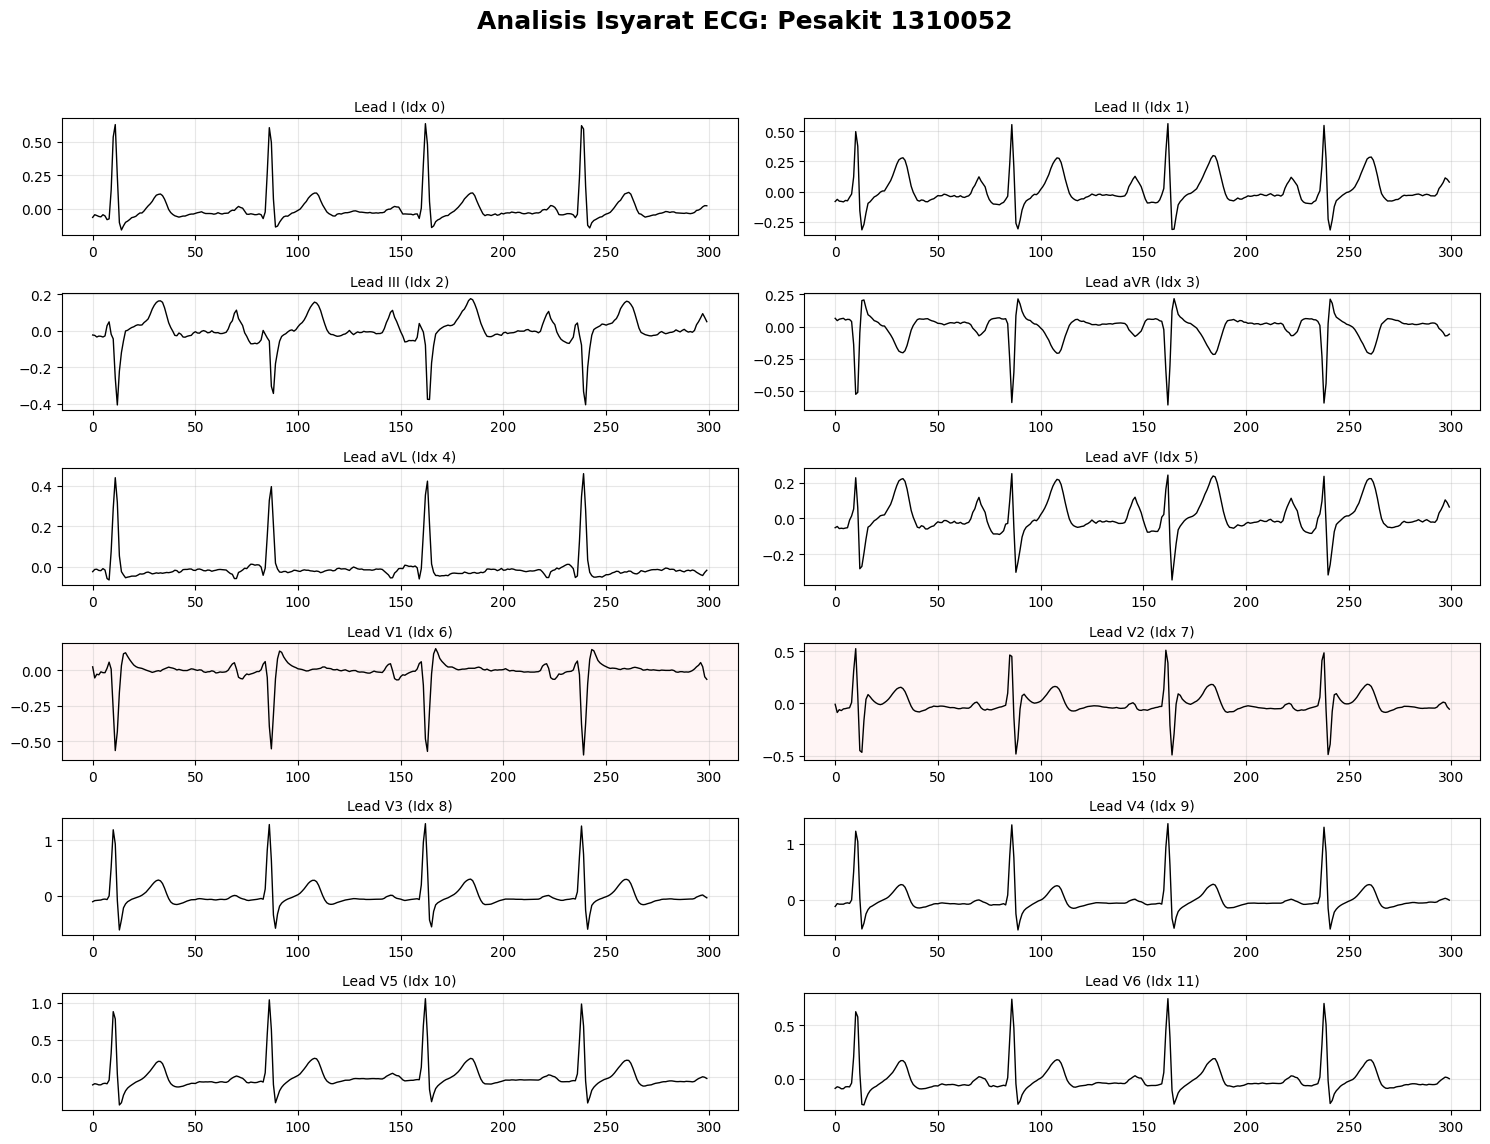

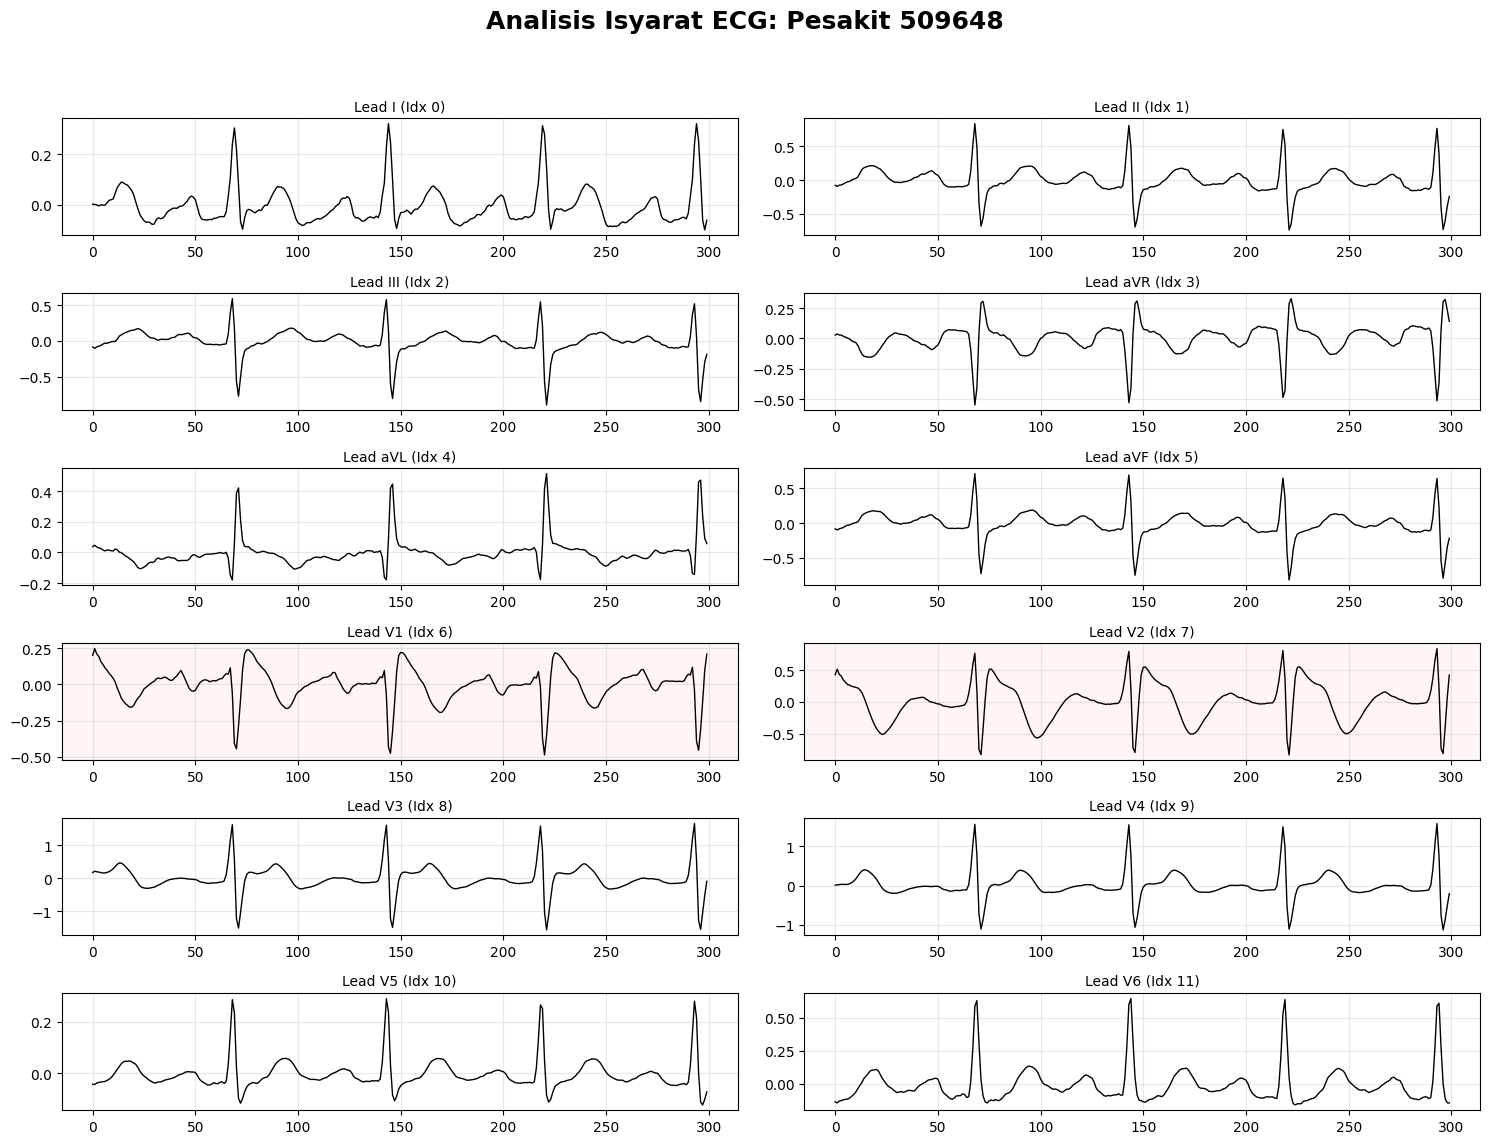


✅ PIPELINE COMPLETED SUCCESSFULLY!
• Jumlah Pesakit Diproses: 363
• Fail Disimpan: ./brugada_dataset_final.pkl

Taburan Kelas (0=Normal, 1=Brugada):
brugada
0    287
1     69
2      7
Name: count, dtype: int64
🔍 Masukkan ID Pesakit (cth: 188981): 487609


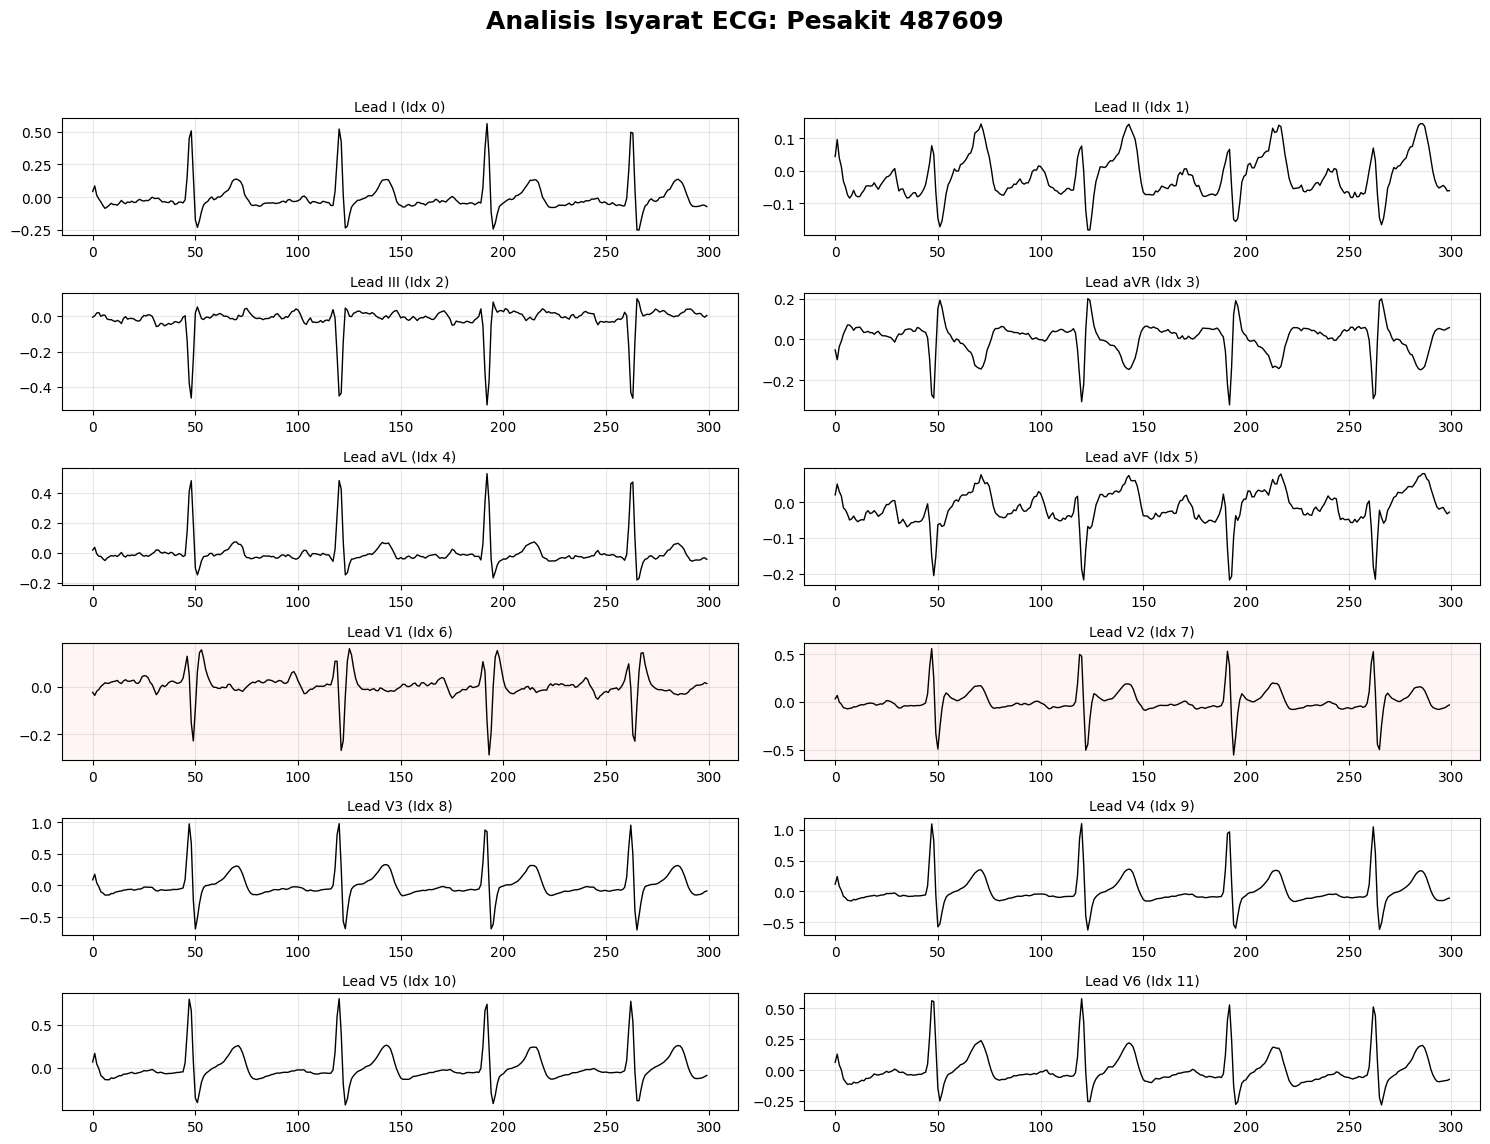

🟢 Diagnosis Dataset: NORMAL
✅ Berjaya memaparkan isyarat pesakit 487609


In [33]:
# =================================================================
# 1. INSTALL & IMPORT LIBRARIES
# =================================================================
# Jalankan ini jika library belum ada
try:
    import wfdb
except:
    !pip install wfdb openpyxl
    import wfdb

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# =================================================================
# 2. AUTO-PATH CONFIGURATION
# =================================================================
def setup_paths():
    """Mengesan lokasi fail secara automatik (Drive atau Sidebar)."""
    # Cuba cari dalam Google Drive dulu
    drive_path = '/content/drive/MyDrive/DATASET BRUGADA/'
    sidebar_path = './'

    if os.path.exists(os.path.join(drive_path, 'PATIENT/')):
        base = drive_path
        print("✅ Sistem: Mengesan data dalam GOOGLE DRIVE.")
    else:
        base = sidebar_path
        print("✅ Sistem: Mengesan data dalam SIDEBAR (Local Content).")

    return {
        'data': os.path.join(base, 'PATIENT/'),
        'meta': os.path.join(base, 'metadata.csv'), # Menggunakan format CSV
        'output': os.path.join(base, 'brugada_dataset_final.pkl')
    }

# =================================================================
# 3. FUNCTION: VISUALIZATION (12-LEADS)
# =================================================================
def plot_professional_ecg(record, pid):
    """Melukis graf ECG 12-lead dengan fokus pada V1 & V2."""
    fig, axs = plt.subplots(6, 2, figsize=(15, 12))
    fig.suptitle(f"Analisis Isyarat ECG: Pesakit {pid}", fontsize=18, fontweight='bold')
    axs = axs.flatten()

    for i in range(12):
        # Ambil 300 sampel (3 saat) untuk paparan yang jelas
        axs[i].plot(record.p_signal[:300, i], color='black', linewidth=1)
        axs[i].set_title(f"Lead {record.sig_name[i]} (Idx {i})", fontsize=10)
        axs[i].grid(True, alpha=0.3)

        # Highlight Lead V1 (Idx 6) dan V2 (Idx 7) - Kawasan Brugada
        if i == 6 or i == 7:
            axs[i].set_facecolor('#FFF5F5') # Warna merah jambu lembut

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =================================================================
# 4. FUNCTION: DATA EXTRACTION
# =================================================================
def process_ecg_data(paths, limit_visuals=3):
    """Membaca fail .hea/.dat dan ekstrak signal V1/V2."""
    if not os.path.exists(paths['data']):
        print(f"❌ RALAT: Folder '{paths['data']}' tidak dijumpai!")
        return pd.DataFrame()

    # Senarai fail .hea sahaja
    patient_ids = [f.replace('.hea', '') for f in os.listdir(paths['data']) if f.endswith('.hea')]
    print(f"🔎 Menjumpai {len(patient_ids)} fail pesakit.")

    extracted_data = []
    visual_count = 0

    for pid in patient_ids:
        try:
            # Baca signal (wfdb akan cari .dat secara automatik)
            record = wfdb.rdrecord(os.path.join(paths['data'], pid))

            # Ekstrak signal V1 & V2
            v1_sig = record.p_signal[:300, 6]
            v2_sig = record.p_signal[:300, 7]

            # Paparan visual untuk pesakit terawal
            if visual_count < limit_visuals:
                plot_professional_ecg(record, pid)
                visual_count += 1

            extracted_data.append({
                'patient_id': str(pid),
                'V1_Signal': v1_sig,
                'V2_Signal': v2_sig
            })
        except Exception as e:
            print(f"⚠️ Skip ID {pid} kerana ralat: {e}")

    return pd.DataFrame(extracted_data)

# =================================================================
# 5. MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    # Langkah A: Sambung Drive (Hanya jika perlu)
    if not os.path.exists('/content/drive'):
        try:
            drive.mount('/content/drive')
        except:
            print("Info: Menjalankan mod Sidebar (Bukan Drive).")

    # Langkah B: Sediakan Alamat Fail
    paths = setup_paths()

    # Langkah C: Jalankan Pengekstrakan
    print("🚀 Memulakan pengekstrakan isyarat ECG...")
    df_signals = process_ecg_data(paths)

    # Langkah D: Gabung dengan metadata.csv & Simpan
    if not df_signals.empty:
        if os.path.exists(paths['meta']):
            try:
                # Menggunakan read_csv mengikut format fail kau
                metadata = pd.read_csv(paths['meta'])

                # Samakan format ID sebagai String
                metadata['patient_id'] = metadata['patient_id'].astype(str)
                df_signals['patient_id'] = df_signals['patient_id'].astype(str)

                # Merge: Isyarat + Label Brugada (0/1)
                final_df = pd.merge(df_signals, metadata[['patient_id', 'brugada']], on='patient_id')

                # Simpan hasil akhir dalam format Pickle (Sesuai untuk AI)
                final_df.to_pickle(paths['output'])

                print("\n" + "="*45)
                print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
                print(f"• Jumlah Pesakit Diproses: {len(final_df)}")
                print(f"• Fail Disimpan: {paths['output']}")
                print("="*45)
                print("\nTaburan Kelas (0=Normal, 1=Brugada):")
                print(final_df['brugada'].value_counts())

            except Exception as merge_err:
                print(f"❌ Ralat semasa menggabung CSV: {merge_err}")
        else:
            print(f"❌ RALAT: Fail '{paths['meta']}' tidak dijumpai di Sidebar/Drive!")
    else:
        print("❌ Tiada data isyarat berjaya diekstrak.")

# =================================================================
# INTERACTIVE SEARCH DASHBOARD (WITH DIAGNOSIS)
# =================================================================
import os
import wfdb
import pandas as pd

search_id = input("🔍 Masukkan ID Pesakit (cth: 188981): ")

try:
    # 1. Plot Graf (Pastikan DATA_DIR dan fungsi plot sudah di-run kat atas)
    # Kita guna path yang kita dah set sebelum ni
    record_path = os.path.join(DATA_DIR, str(search_id))
    record = wfdb.rdrecord(record_path)

    # Panggil fungsi lukis (Guna nama fungsi yang kau ada kat atas)
    try:
        plot_professional_ecg(record, search_id)
    except NameError:
        plot_ecg_sample(record, search_id)

    # 2. Cari Info Diagnosis dalam metadata.csv
    # Pastikan 'metadata' adalah dataframe yang kita dah load kat atas
    diagnosis_row = metadata[metadata['patient_id'] == str(search_id)]

    if not diagnosis_row.empty:
        label = diagnosis_row['brugada'].values[0]

        # Tukar nombor label kepada perkataan
        if label == 1:
            hasil = "BRUGADA TYPE 1 (Coved Type)"
            warna = "🔴"
        elif label == 2:
            hasil = "BRUGADA TYPE 2 (Saddle-back Type)"
            warna = "🟠"
        else:
            hasil = "NORMAL"
            warna = "🟢"

        print(f"{warna} Diagnosis Dataset: {hasil}")
        print(f"✅ Berjaya memaparkan isyarat pesakit {search_id}")
    else:
        print(f"⚠️ Isyarat dijumpai, tapi ID {search_id} tiada dalam metadata.csv")

except Exception as e:
    print(f"❌ ID {search_id} tidak dijumpai atau ralat sistem.")
    print(f"Detail: {e}")